In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

Step1: Basic Understanding of the Dataset

In [7]:
df = pd.read_csv("C:\\Users\\dsasu\\Desktop\\DATASUTRAM\\MJ\\Zomato Delivery Time Prediction\\dataset\\raw\\Zomato Dataset.csv")
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,11:45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55,20:10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,24:05:00,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,13:40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26


In [8]:
df.shape

(45584, 20)

DATASET STRUCTURE ANALYSIS

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

Insights

Dataset_Shape : 45,584 → good dataset size

Total Features : 20 → manageable

--- Perfect for regression

Production insight: This is medium-sized tabular dataset.

DATA QUALITY CHECK

Check Missing values


In [10]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64

Check duplicates


In [12]:
df.duplicated().sum()

0

Check Invalid Values

In [14]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


#### Insights:

###### Delivery Person Age --- 15 Years Minimum Age --- Not Allowed Underaged Driver 
###### Delivery Person Ratings --- 6 Rating Maximum ---- Since Ratings should be out of 5 
###### Restaurant Latitude and Longitude --- Since its Latitude and Longitude are India Based 
###### So Latitude should be 6 to 37 and Longitude Should be in range 68 to 97 Rest all are Invalid
###### Vehicle Condition --- Minimum Value -- 0 - Worst and Maximum Value -- 3 - Best
###### Multiple Deliveries -- Most are Single Deliveries

Univariate Analysis


Numerical Values

<Axes: >

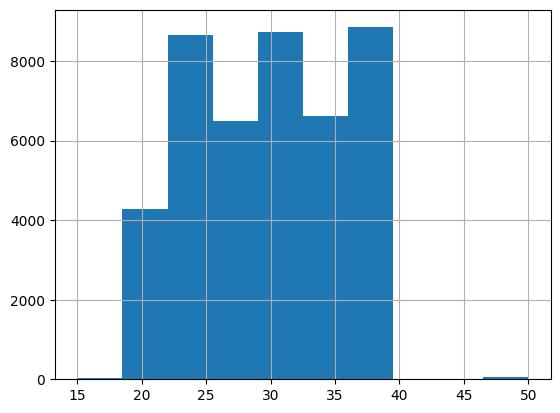

In [15]:
df["Delivery_person_Age"].hist()

Check Distribution

In [16]:
df["Weather_conditions"].value_counts()

Weather_conditions
Fog           7653
Stormy        7584
Cloudy        7533
Sandstorms    7494
Windy         7422
Sunny         7282
Name: count, dtype: int64

Bivariate Analysis (Feature vs Target)

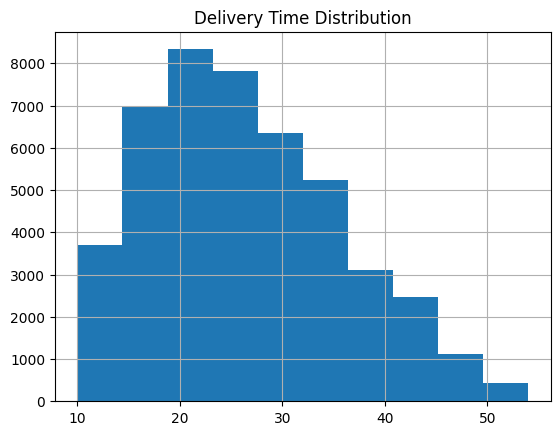

In [18]:
df["Time_taken (min)"].hist()
plt.title("Delivery Time Distribution")
plt.show()

#### Its Right Skewed

In [21]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    
    R = 6371
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


df["distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

In [25]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'distance_km'],
      dtype='object')

In [27]:
df['Time_Orderd']

0        21:55
1        14:55
2        17:30
3        09:20
4        19:50
         ...  
45579    11:35
45580    19:55
45581    23:50
45582    13:35
45583    17:10
Name: Time_Orderd, Length: 45584, dtype: object

In [31]:
#df["Time_Ordered"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M")

df["Time_Orderd"].unique()[:50]

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '20:40', '21:15', '20:20', '22:30', '08:15', '19:30', '12:25',
       '18:35', '20:35', '23:20', '21:20', '23:35', '22:35', '23:25',
       '13:35', '21:35', '18:55', '14:15', '0.458333333', '09:45',
       '08:40', '0.958333333', '17:25', nan, '19:45', '19:10', '10:55',
       '21:40', '0.791666667', '16:45', '11:30', '15:10', '22:45',
       '22:10', '20:45', '22:50', '17:55', '09:25', '20:15', '22:25',
       '22:40', '23:50', '15:25'], dtype=object)

In [34]:
import pandas as pd
import numpy as np


def convert_mixed_time(value):

    if pd.isna(value):
        return np.nan

    value = str(value)

    # Case 1: HH:MM format
    if ":" in value:
        return pd.to_datetime(value, format="%H:%M", errors="coerce")

    # Case 2: fractional Excel format
    try:
        float_val = float(value)
        hours = int(float_val * 24)
        minutes = int((float_val * 24 * 60) % 60)

        return pd.to_datetime(f"{hours}:{minutes}", format="%H:%M")

    except:
        return np.nan

df["Time_Ordered"] = df["Time_Orderd"].apply(convert_mixed_time)

In [35]:
pd.set_option("display.max_columns",None)

In [36]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,Time_Ordered
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,1900-01-01 21:55:00
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,1900-01-01 14:55:00
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,1900-01-01 17:30:00
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,1900-01-01 09:20:00
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,1900-01-01 19:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,11:45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,1.489846,1900-01-01 11:35:00
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55,20:10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36,11.007735,1900-01-01 19:55:00
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,24:05:00,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,4.657195,1900-01-01 23:50:00
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,13:40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,6.232393,1900-01-01 13:35:00


In [37]:
df["order_hour"] = df["Time_Ordered"].dt.hour

In [38]:
df["order_minute"] = df["Time_Ordered"].dt.minute

In [39]:
df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M",
    errors="coerce"
)

df["pickup_delay_minutes"] = (
    df["Time_Order_picked"] - df["Time_Ordered"]
).dt.total_seconds() / 60

df["pickup_delay_minutes"].fillna(
    df["pickup_delay_minutes"].median(),
    inplace=True
)

In [40]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="%d-%m-%Y"
)

df["order_day_of_week"] = df["Order_Date"].dt.dayofweek

In [41]:
df["is_weekend"] = df["order_day_of_week"].isin([5,6]).astype(int)

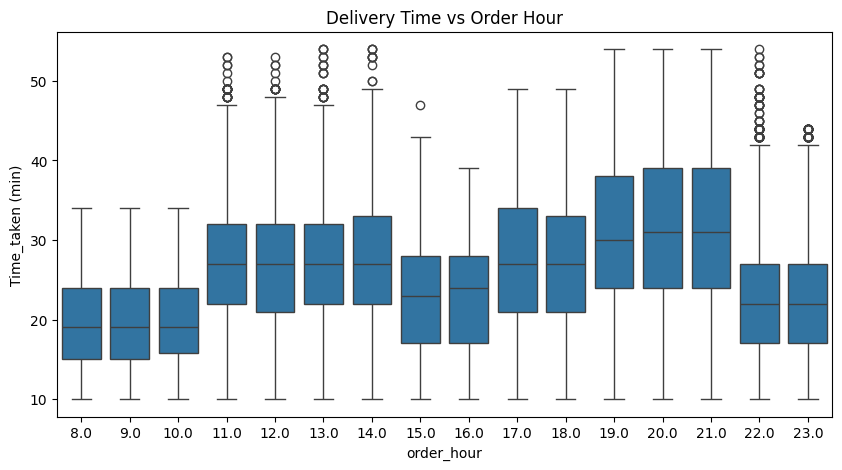

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["order_hour"],
    y=df["Time_taken (min)"]
)

plt.title("Delivery Time vs Order Hour")
plt.show()

In [43]:
df.groupby("order_hour")["Time_taken (min)"].mean().sort_values(ascending=False)

order_hour
20.0    31.178528
21.0    31.090928
19.0    30.862158
14.0    27.543933
13.0    27.529755
17.0    27.477559
18.0    27.276178
11.0    27.165158
12.0    26.826233
15.0    23.194731
22.0    23.145458
16.0    22.932903
23.0    22.435314
8.0     19.580627
9.0     19.543914
10.0    19.457875
Name: Time_taken (min), dtype: float64

In [44]:
peak_hours = (
    df.groupby("order_hour")["Time_taken (min)"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df["is_peak_hour"] = df["order_hour"].isin(peak_hours).astype(int)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45584 non-null  object        
 1   Delivery_person_ID           45584 non-null  object        
 2   Delivery_person_Age          43730 non-null  float64       
 3   Delivery_person_Ratings      43676 non-null  float64       
 4   Restaurant_latitude          45584 non-null  float64       
 5   Restaurant_longitude         45584 non-null  float64       
 6   Delivery_location_latitude   45584 non-null  float64       
 7   Delivery_location_longitude  45584 non-null  float64       
 8   Order_Date                   45584 non-null  datetime64[ns]
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            40577 non-null  datetime64[ns]
 11  Weather_conditions           44968 non-nu

In [47]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


TARGET = "Time_taken (min)"


def get_features_and_target(df):

    # Drop useless columns
    df = df.drop(columns=[
        "ID",
        "Delivery_person_ID",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "Order_Date",
        "Time_Orderd",
        "Time_Order_picked",
        "Time_Ordered"
    ])

    X = df.drop(TARGET, axis=1)
    y = df[TARGET]

    return X, y


def create_preprocessor():

    categorical_features = [

        "Weather_conditions",
        "Road_traffic_density",
        "Type_of_order",
        "Type_of_vehicle",
        "Festival",
        "City"

    ]

    numerical_features = [

        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Vehicle_condition",
        "multiple_deliveries",
        "distance_km",
        "order_hour",
        "order_minute",
        "pickup_delay_minutes",
        "order_day_of_week",
        "is_weekend",
        "is_peak_hour"

    ]

    preprocessor = ColumnTransformer(

        transformers=[

            (
                "num",
                StandardScaler(),
                numerical_features
            ),

            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        ]
    )

    return preprocessor


def split_data(df):

    X, y = get_features_and_target(df)

    return train_test_split(

        X,
        y,
        test_size=0.2,
        random_state=42
    )

In [48]:
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.features.preprocess import split_data, create_preprocessor


def train():

    df = pd.read_csv("data/processed/processed_data.csv")

    X_train, X_test, y_train, y_test = split_data(df)

    preprocessor = create_preprocessor()

    model = Pipeline(

        steps=[

            ("preprocessor", preprocessor),

            ("regressor", LinearRegression())

        ]
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    print("MAE:", mean_absolute_error(y_test, predictions))

    print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)

    print("R2 Score:", r2_score(y_test, predictions))

    joblib.dump(

        model,

        "models/delivery_time_model.pkl"

    )

    print("Model saved successfully")



train()

ModuleNotFoundError: No module named 'src'